In [1]:
import ccxt
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [54]:
# Initialize the exchange
exchange = ccxt.binance({'enableRateLimit': True})

def fetch_large_ohlcv(symbol, timeframe, since):
    all_ohlcv = []
    
    while True:
        # Fetch a chunk of data
        data = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
        
        if not data:
            break
            
        all_ohlcv.extend(data)
        
        # Update 'since' to the timestamp of the last candle received
        # to get the next chunk in the next iteration
        since = data[-1][0] + 1
        
        # Respect API rate limits
        time.sleep(0.1) 
        
        # Stop if we have enough data (or reached now)
        if len(data) < 1000:
            break
            
    return all_ohlcv

# Example usage:
# Get BTC/USDT 1-minute data from a specific start date
since = exchange.parse8601('2022-01-01T00:00:00Z')
ohlcv_data = fetch_large_ohlcv('BTC/USDT', '1m', since)

# Convert to Pandas DataFrame for analysis
df = pd.DataFrame(ohlcv_data, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

## volume states

### position

is the position exceptionally high or low?

### velocity

is the velocity exceptionally high or low? is it close to 0?

### acceleration 

is acceleration high, low or close to 0?

In [145]:
df["diff1"] = df["volume"].diff()
df["diff2"] = df["diff1"].diff()

WINDOW = 20
THRESHOLD = 1.5
EPSILON_MULT = 0.2


def classify_state(df, col_name, prefix):
    mean = df[col_name].rolling(window=WINDOW, min_periods=1).mean()
    std = df[col_name].rolling(window=WINDOW, min_periods=1).std().fillna(0)

    # Threshold boundaries
    upper = mean + (THRESHOLD * std)
    lower = mean - (THRESHOLD * std)
    near_zero_upper = mean + (EPSILON_MULT * std)
    near_zero_lower = mean - (EPSILON_MULT * std)

    # 4 explicit, non-overlapping conditions
    conditions = [
        df[col_name] > upper,  # High
        df[col_name] < lower,  # Low
        (df[col_name] >= near_zero_lower) & (df[col_name] <= near_zero_upper),  # Flat
    ]

    choices = [f"High_{prefix}", f"Low_{prefix}", f"Flat_{prefix}"]
    # The absolute fallback is explicitly "Normal"
    default = f"Normal_{prefix}"

    return np.select(conditions, choices, default=default)


# Apply classifications
df["vol_state"] = classify_state(df, "volume", "Vol")
df["velocity_state"] = classify_state(df, "diff1", "Vel")
df["acceleration_state"] = classify_state(df, "diff2", "Acc")

# Combine them into the single Master State string
df["master_state"] = (
    df["vol_state"] + " | " + df["velocity_state"] + " | " + df["acceleration_state"]
)

In [146]:
import numpy as np
import pandas as pd

# 1. Calculate the differentials
df["diff1"] = df["volume"].diff()
df["diff2"] = df["diff1"].diff()

# Set your rolling window (adjust based on your data frequency)
WINDOW = 20
# Threshold multiplier (e.g., 1.5 standard deviations for "significant")
THRESHOLD = 1.5
# Epsilon multiplier for "close to 0" (e.g., within 0.2 standard deviations)
EPSILON_MULT = 0.2


# 2. Helper function to categorize states using rolling metrics
def classify_state(df, col_name, prefix):
    # Calculate rolling baseline
    mean = df[col_name].rolling(window=WINDOW, min_periods=1).mean()
    std = df[col_name].rolling(window=WINDOW, min_periods=1).std().fillna(0)

    # Define thresholds
    upper = mean + (THRESHOLD * std)
    lower = mean - (THRESHOLD * std)
    near_zero_upper = mean + (EPSILON_MULT * std)
    near_zero_lower = mean - (EPSILON_MULT * std)

    # Conditions
    conditions = [
        df[col_name] > upper,
        df[col_name] < lower,
        (df[col_name] >= near_zero_lower) & (df[col_name] <= near_zero_upper),
    ]

    # Labels
    choices = [f"High_{prefix}", f"Low_{prefix}", f"Flat_{prefix}"]
    default = f"Normal_{prefix}"

    return np.select(conditions, choices, default=default)


# 3. Apply classifications
df["vol_state"] = classify_state(df, "volume", "Vol")
df["velocity_state"] = classify_state(df, "diff1", "Vel")
df["acceleration_state"] = classify_state(df, "diff2", "Acc")

# 4. Combine them into a single Master State string
df["master_state"] = (
    df["vol_state"] + " | " + df["velocity_state"] + " | " + df["acceleration_state"]
)

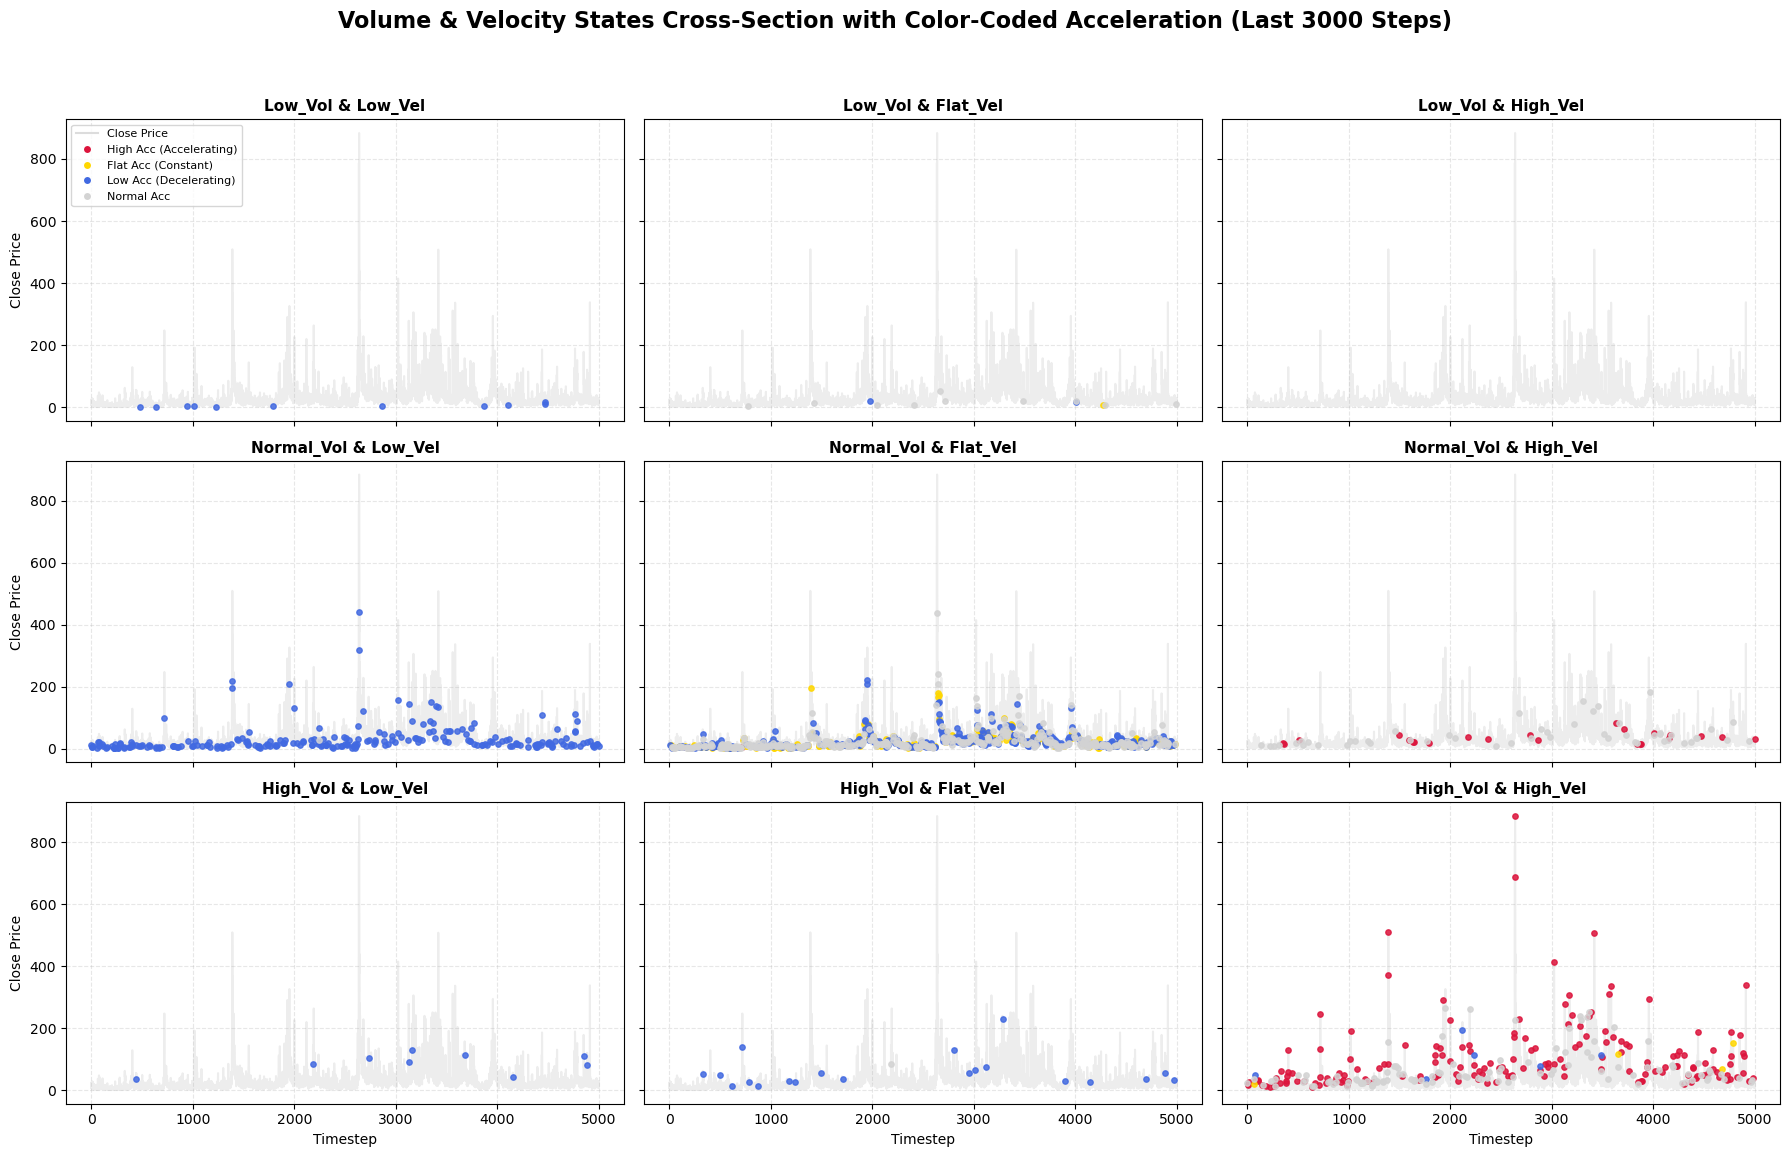

In [4]:
# --- 2. PLOT THE 3D ANALYSIS GRID ---
# Filter for the last 3000 timesteps to look at recent behavior
plot_df = df[130000:135000].copy().reset_index()

vol_states = ["Low_Vol", "Normal_Vol", "High_Vol"]
vel_states = ["Low_Vel", "Flat_Vel", "High_Vel"]

# Colors mapped to the Acceleration (2nd Differential) state
acc_colors = {
    "High_Acc": "crimson",  # Rate of volume change is speeding up
    "Flat_Acc": "gold",  # Rate of volume change is flat/constant
    "Low_Acc": "royalblue",  # Rate of volume change is slowing down
    "Normal_Acc": "lightgray",  # Average/normal acceleration
}

# Create a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey=True)
fig.suptitle(
    "Volume & Velocity States Cross-Section with Color-Coded Acceleration (Last 3000 Steps)",
    fontsize=16,
    fontweight="bold",
    y=0.96,
)

for i, vol_s in enumerate(vol_states):
    for j, vel_s in enumerate(vel_states):
        ax = axes[i, j]

        # 1. Plot background Close price in light gray
        ax.plot(
            plot_df.index,
            plot_df["volume"],
            color="gainsboro",
            alpha=0.5,
            label="Close Price",
            zorder=1,
        )

        # 2. Filter data points falling into the current (Volume, Velocity) grid block
        joint_mask = (plot_df["vol_state"] == vol_s) & (
            plot_df["velocity_state"] == vel_s
        )
        state_df = plot_df[joint_mask]

        if not state_df.empty:
            # 3. Scatter points colored by their Acceleration (2nd differential) state
            for acc_s, color in acc_colors.items():
                acc_mask = state_df["acceleration_state"] == acc_s
                sub_df = state_df[acc_mask]
                if not sub_df.empty:
                    label_name = acc_s.replace("_", " ")
                    ax.scatter(
                        sub_df.index,
                        sub_df["volume"],
                        color=color,
                        s=15,
                        label=label_name,
                        zorder=2,
                        alpha=0.85,
                    )

        # Layout Formatting
        ax.set_title(f"{vol_s} & {vel_s}", fontsize=11, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.3)

        # Legend on the first subplot
        if i == 0 and j == 0:
            from matplotlib.lines import Line2D

            legend_elements = [
                Line2D([0], [0], color="gainsboro", lw=1.5, label="Close Price"),
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    markerfacecolor="crimson",
                    markersize=6,
                    label="High Acc (Accelerating)",
                ),
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    markerfacecolor="gold",
                    markersize=6,
                    label="Flat Acc (Constant)",
                ),
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    markerfacecolor="royalblue",
                    markersize=6,
                    label="Low Acc (Decelerating)",
                ),
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    markerfacecolor="lightgray",
                    markersize=6,
                    label="Normal Acc",
                ),
            ]
            ax.legend(handles=legend_elements, loc="upper left", fontsize=8)

        # Label outer axes only
        if i == 2:
            ax.set_xlabel("Timestep")
        if j == 0:
            ax.set_ylabel("Close Price")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

low velocity ~ low acceleration

normal volume & flat velocity ~ flat/normal acceleration

normal volume & high velocity ~ high acceleration\
high volume & high velocity ~ high acceleration

In [147]:


# =======================================================
# 1. Calculate Future Differences & Directional States
# =======================================================
df["target_change_1"] = df["volume"].shift(-1) - df["volume"]
df["target_change_5"] = df["volume"].shift(-5) - df["volume"]

df["goes_up_t1"] = (df["target_change_1"] > 0).astype(int)
df["goes_up_t5"] = (df["target_change_5"] > 0).astype(int)
df["goes_down_t1"] = (df["target_change_1"] < 0).astype(int)
df["goes_down_t5"] = (df["target_change_5"] < 0).astype(int)

# =======================================================
# 2. Aggregate and Analyze
# =======================================================
# =======================================================
# 2. Aggregate, Filter for Significance, and Analyze
# =======================================================
analysis_df = (
    df.groupby("master_state")
    .agg(
        occurrences=("volume", "count"),
        avg_change_t1=("target_change_1", "mean"),
        prob_up_t1=("goes_up_t1", "mean"),
        prob_down_t1=("goes_down_t1", "mean"),
        avg_change_t5=("target_change_5", "mean"),
        prob_up_t5=("goes_up_t5", "mean"),
        prob_down_t5=("goes_down_t5", "mean"),
    )
    .reset_index()
)

# ----------------------------------------------------
# STATISTICAL SIGNIFICANCE FILTER
# Adjust 'MIN_SIGNIFICANT_SAMPLES' based on your data size.
# 30 is the standard statistical rule of thumb.
# ----------------------------------------------------
MIN_SIGNIFICANT_SAMPLES = 100 

# Drop rows that do not meet the sample size threshold
analysis_df = analysis_df[analysis_df["occurrences"] >= MIN_SIGNIFICANT_SAMPLES]

# Sort by the highest predictability at t+1 (either strongly up or strongly down)
# This highlights your most actionable states first
analysis_df["predictability_bias"] = (analysis_df["prob_up_t1"] - 0.5).abs()
analysis_df = analysis_df.sort_values(by="predictability_bias", ascending=False).drop(columns=["predictability_bias"])
display(analysis_df)

,master_state,occurrences,avg_change_t1,prob_up_t1,prob_down_t1,avg_change_t5,prob_up_t5,prob_down_t5
22,Low_Vol | Low_Vel | Normal_Acc,543,8.352240,0.887661,0.112339,9.984952,0.872928,0.127072
21,Low_Vol | Low_Vel | Low_Acc,766,8.411562,0.885117,0.114883,10.468052,0.898172,0.101828
11,High_Vol | High_Vel | High_Acc,46852,-34.037582,0.115619,0.884381,-44.360436,0.079335,0.920665
26,Low_Vol | Normal_Vel | Normal_Acc,5342,9.393686,0.880195,0.119805,12.683715,0.887683,0.112317
23,Low_Vol | Normal_Vel | Flat_Acc,1690,9.391935,0.873373,0.126627,12.887445,0.888757,0.111243
13,High_Vol | High_Vel | Normal_Acc,31455,-17.990367,0.138197,0.861803,-23.808625,0.106215,0.893785
10,High_Vol | High_Vel | Flat_Acc,1003,-26.266330,0.157527,0.842473,-37.019420,0.077767,0.922233
14,High_Vol | Low_Vel | Low_Acc,1432,-25.678833,0.175279,0.824721,-43.614880,0.104749,0.895251
18,High_Vol | Normal_Vel | Low_Acc,5968,-25.711704,0.178117,0.821883,-36.715403,0.121146,0.878854
17,High_Vol | Normal_Vel | High_Acc,1943,-14.759210,0.180648,0.819352,-21.387196,0.128152,0.871848


In [148]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# ==========================================
# 1. Prepare data (Memory-efficiently)
# ==========================================
df["rolling_mean"] = df["volume"].rolling(window=WINDOW, min_periods=1).mean()
df["rolling_std"] = df["volume"].rolling(window=WINDOW, min_periods=1).std().fillna(1)
df["dist_from_mean"] = (df["volume"] - df["rolling_mean"]) / df["rolling_std"]

df["delta_v_1"] = df["volume"].shift(-1) - df["volume"]
df["delta_v_5"] = df["volume"].shift(-5) - df["volume"]

# Drop NaNs and select only the columns we need to keep memory footprint low
regression_data = df[["dist_from_mean", "delta_v_1", "delta_v_5"]].dropna().copy()

# ==========================================
# TEST 1: Subsampled Regression (Statistically robust & Fast)
# ==========================================
# Instead of 1.3 million rows, we randomly sample 50,000 rows.
# This is more than enough for a highly precise regression analysis.
SAMPLE_SIZE = 50000
if len(regression_data) > SAMPLE_SIZE:
    reg_sample = regression_data.sample(n=SAMPLE_SIZE, random_state=42)
else:
    reg_sample = regression_data

def run_reversion_regression(data, target_col):
    X = data["dist_from_mean"]
    X = sm.add_constant(X)
    y = data[target_col]
    
    model = sm.OLS(y, X).fit()
    return model.params["dist_from_mean"], model.pvalues["dist_from_mean"], model.rsquared

coef_1, p_1, r2_1 = run_reversion_regression(reg_sample, "delta_v_1")
coef_5, p_5, r2_5 = run_reversion_regression(reg_sample, "delta_v_5")

# ==========================================
# TEST 2: Localized ADF Test (Consecutive Slice)
# ==========================================
# ADF requires continuous time-series data (not random sampling).
# We take a continuous block of 20,000 rows from the middle of the dataset.
ADF_SAMPLE_SIZE = 20000
volume_series = df["volume"].dropna()

if len(volume_series) > ADF_SAMPLE_SIZE:
    # Take a continuous slice from the middle of your dataset
    start_idx = len(volume_series) // 2
    adf_sample = volume_series.iloc[start_idx : start_idx + ADF_SAMPLE_SIZE]
else:
    adf_sample = volume_series

# Run ADF with a restricted maxlag to keep memory usage extremely low
adf_result = adfuller(adf_sample, maxlag=20, autolag="AIC")

# ==========================================
# Present the Results
# ==========================================
print("=== MEMORY-SAFE MEAN REVERSION ANALYSIS ===")
print(f"Total Rows: {len(df):,}")
print(f"Regression Sample Size: {len(reg_sample):,}")
print(f"ADF Continuous Sample Size: {len(adf_sample):,}")
print("-" * 50)

print(f"\n1. REGRESSION ANALYSIS (Change vs. Distance from Mean):")
print(f"   [t+1 Timestep Change]")
print(f"     - Reversion Coefficient: {coef_1:.4f}")
print(f"     - P-value:               {p_1:.4e}")
print(f"     - R-squared:             {r2_1:.4f}")

print(f"\n   [t+5 Timestep Change]")
print(f"     - Reversion Coefficient: {coef_5:.4f}")
print(f"     - P-value:               {p_5:.4e}")
print(f"     - R-squared:             {r2_5:.4f}")

print(f"\n2. ADF UNIT-ROOT TEST (Stationarity on continuous slice):")
print(f"   - ADF Statistic:           {adf_result[0]:.4f}")
print(f"   - p-value:                 {adf_result[1]:.4e}")
print("   - Critical Values:")
for key, value in adf_result[4].items():
    print(f"       {key}: {value:.4f}")

C:\Users\Mark Brezina\AppData\Local\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


=== MEMORY-SAFE MEAN REVERSION ANALYSIS ===
Total Rows: 1,333,884
Regression Sample Size: 50,000
ADF Continuous Sample Size: 20,000
--------------------------------------------------

1. REGRESSION ANALYSIS (Change vs. Distance from Mean):
   [t+1 Timestep Change]
     - Reversion Coefficient: -8.3050
     - P-value:               0.0000e+00
     - R-squared:             0.0910

   [t+5 Timestep Change]
     - Reversion Coefficient: 0.0000
     - P-value:               nan
     - R-squared:             nan

2. ADF UNIT-ROOT TEST (Stationarity on continuous slice):
   - ADF Statistic:           -16.1382
   - p-value:                 4.7060e-29
   - Critical Values:
       1%: -3.4307
       5%: -2.8617
       10%: -2.5668


In [154]:
import pandas as pd

# =====================================================================
# 1. PREPARATION: Map Probabilities Back to the Primary DataFrame (df)
# =====================================================================
# Save your original index to restore it perfectly after the merge
original_index = df.index

# Merge the analysis probabilities back into 'df' using 'master_state'
df_backtest = df.merge(
    analysis_df[['master_state', 'prob_up_t1', 'prob_up_t5', 'prob_down_t1', 'prob_down_t5']], 
    on='master_state', 
    how='left'
)

# Restore your original index
df_backtest.index = original_index

# If 'df_backtest' has missing values (due to states excluded by MIN_SIGNIFICANT_SAMPLES),
# we fill them with 0 so they don't trigger trades.
prob_cols = ['prob_up_t1', 'prob_up_t5', 'prob_down_t1', 'prob_down_t5']
df_backtest[prob_cols] = df_backtest[prob_cols].fillna(0)

# Ensure we have a close price to calculate trade returns
if 'close' not in df_backtest.columns:
    df_backtest['close'] = (df_backtest['high'] + df_backtest['low']) / 2


# =====================================================================
# 2. BACKTEST ENGINE
# =====================================================================

# Define fees
fee_per_transaction = 0.0007
round_trip_fee = fee_per_transaction * 2 

# Track state variables
position = 0       # 0 = flat, 1 = long
entry_price = 0.0
entry_time = None
trades = []

PROB_THRESHOLD = 0.75

for i in range(len(df_backtest)):
    current_price = df_backtest['close'].iloc[i]
    current_time = df_backtest.index[i]
    
    # Extract probabilities for the current step
    p_up_t1 = df_backtest['prob_up_t1'].iloc[i]
    p_up_t5 = df_backtest['prob_up_t5'].iloc[i]
    p_down_t1 = df_backtest['prob_down_t1'].iloc[i]
    p_down_t5 = df_backtest['prob_down_t5'].iloc[i]
    
    # Define boolean triggers
    expect_volume_up = (p_up_t1 > PROB_THRESHOLD) or (p_up_t5 > PROB_THRESHOLD)
    expect_volume_down = (p_down_t1 > PROB_THRESHOLD) or (p_down_t5 > PROB_THRESHOLD)
    
    # --- 1. HANDLE EXISTING POSITIONS ---
    if position == 1:  # Currently Long
        # Exit Long when we expect volume to go down
        if expect_volume_up:
            gross_pnl = (current_price - entry_price) / entry_price
            net_pnl = gross_pnl - round_trip_fee
            
            trades.append({
                'Type': 'Long',
                'Entry Time': entry_time,
                'Exit Time': current_time,
                'Entry Price': entry_price,
                'Exit Price': current_price,
                'Gross PnL (%)': round(gross_pnl * 100, 3),
                'Net PnL (%)': round(net_pnl * 100, 3)
            })
            position = 0  # Return to flat
            
    # --- 2. LOOK FOR NEW ENTRIES (Only if flat) ---
    elif position == 0:
        # Enter Long when we expect volume to go up
        if expect_volume_down:
            position = 1
            entry_price = current_price
            entry_time = current_time


# =====================================================================
# 3. PERFORMANCE METRICS GENERATION
# =====================================================================
trades_df = pd.DataFrame(trades)

print("\n=== Volume Probability Backtest Performance Summary ===")
if not trades_df.empty:
    total_trades = len(trades_df)
    winning_trades = trades_df[trades_df['Net PnL (%)'] > 0]
    win_rate = (len(winning_trades) / total_trades) * 100
    
    total_gross_pnl = trades_df['Gross PnL (%)'].sum()
    total_net_pnl = trades_df['Net PnL (%)'].sum()
    avg_net_pnl = trades_df['Net PnL (%)'].mean()
    
    print(f"Total Trades Executed : {total_trades}")
    print(f"Net Win Rate          : {win_rate:.2f}%")
    print(f"Cumulative Gross Return: {total_gross_pnl:.2f}%")
    print(f"Cumulative Net Return  : {total_net_pnl:.2f}% (After Fees)")
    print(f"Average Net Return/Trade: {avg_net_pnl:.3f}%")
    
    print("\n--- Last 10 Executed Trades (Including Fees) ---")
    print(trades_df[['Type', 'Entry Price', 'Exit Price', 'Gross PnL (%)', 'Net PnL (%)']].tail(10).to_string(index=False))
else:
    print("No trades were triggered. Verify your probability threshold (0.75) or sample size limit.")


=== Volume Probability Backtest Performance Summary ===
Total Trades Executed : 6045
Net Win Rate          : 34.90%
Cumulative Gross Return: 68.70%
Cumulative Net Return  : -777.60% (After Fees)
Average Net Return/Trade: -0.129%

--- Last 10 Executed Trades (Including Fees) ---
Type  Entry Price  Exit Price  Gross PnL (%)  Net PnL (%)
Long     63336.01    62810.00         -0.831       -0.971
Long     62806.00    62987.14          0.288        0.148
Long     62956.53    62956.14         -0.001       -0.141
Long     62910.00    62333.98         -0.916       -1.056
Long     62319.99    62298.01         -0.035       -0.175
Long     62197.99    62328.81          0.210        0.070
Long     62276.00    62320.00          0.071       -0.069
Long     62274.79    61993.59         -0.452       -0.592
Long     62051.99    62564.19          0.825        0.685
Long     62539.99    64783.23          3.587        3.447


## prices

### position

is the position exceptionally high or low?

is internal price ranges expanding or contracting?

### Local, longterm, alltime low or high reversions

1. all time high
2. all time low, since last all time high
3. local time high, since last all time low
4. local time low, since last local time high

all must be corrected for improper resets.

In [56]:
import numpy as np
import pandas as pd

# 0. Row positions array for duplicate-safe grouping
row_positions = np.arange(len(df))

# --- LAYER 1: All-Time High ---
df['ATH'] = df['high'].cummax()
df['is_ath'] = df['high'] >= df['ATH']

# --- Calculate distance in terms of row-indices ---
row_indices = pd.Series(np.arange(len(df)), index=df.index)
df['last_ath_idx'] = row_indices.where(df['is_ath']).ffill()
df['steps_since_ath'] = row_indices - df['last_ath_idx']

# --- LAYER 2: All-Time Low (resets on ATH) ---
df['ATL'] = df.groupby('last_ath_idx')['low'].cummin()

# Track ATL triggers
is_atl = (df['low'].values == df['ATL'].values)
atl_triggers = np.where(is_atl, row_positions, np.nan)
df['last_atl_idx'] = pd.Series(atl_triggers).ffill().values

# --- LAYER 3: Long-Term High (resets on ATL) ---
df['long_term_high'] = df.groupby('last_atl_idx')['high'].cummax()

# --- LAYER 4: Long-Term Low (resets on LTH) ---
# Identify when a new LTH is established
is_lth = (df['high'].values == df['long_term_high'].values)
lth_triggers = np.where(is_lth, row_positions, np.nan)
df['last_lth_idx'] = pd.Series(lth_triggers).ffill().values

# Group by the LTH index and calculate cumulative minimum
df['long_term_low'] = df.groupby('last_lth_idx')['low'].cummin()

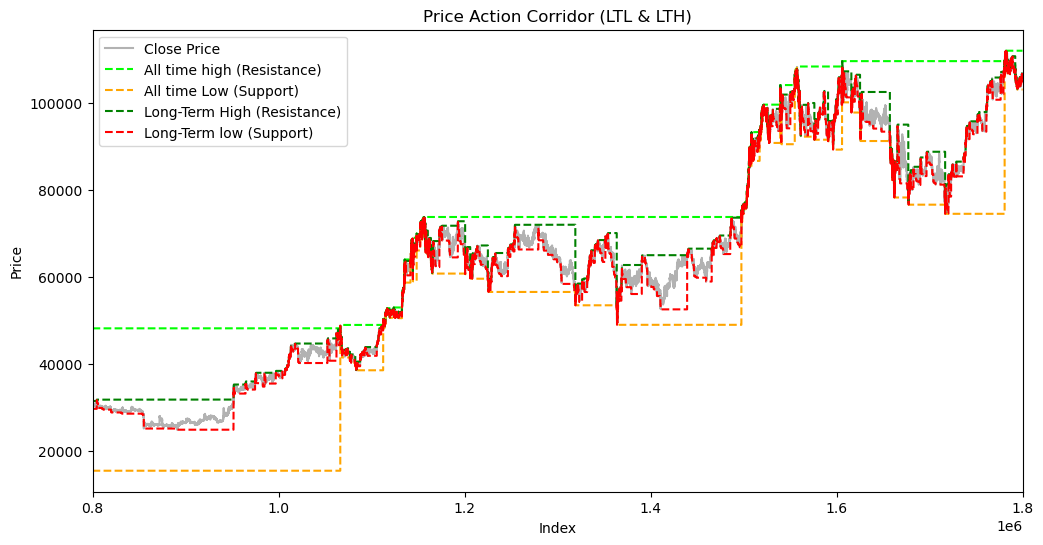

In [58]:
import matplotlib.pyplot as plt

t1, t2 = 800_000, 1_800_000
df_cutout = df.iloc[t1:t2].copy()

plt.figure(figsize=(12, 6))
plt.plot(df_cutout.index, df_cutout['close'], label='Close Price', color='gray', alpha=0.6)
plt.plot(df_cutout.index, df_cutout['ATH'], label='All time high (Resistance)', color='lime', linestyle='--')
plt.plot(df_cutout.index, df_cutout['ATL'], label='All time Low (Support)', color='orange', linestyle='--')
plt.plot(df_cutout.index, df_cutout['long_term_high'], label='Long-Term High (Resistance)', color='green', linestyle='--')
plt.plot(df_cutout.index, df_cutout['long_term_low'], label='Long-Term low (Support)', color='red', linestyle='--')

plt.title("Price Action Corridor (LTL & LTH)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()
plt.xlim(t1, t2)
plt.show()

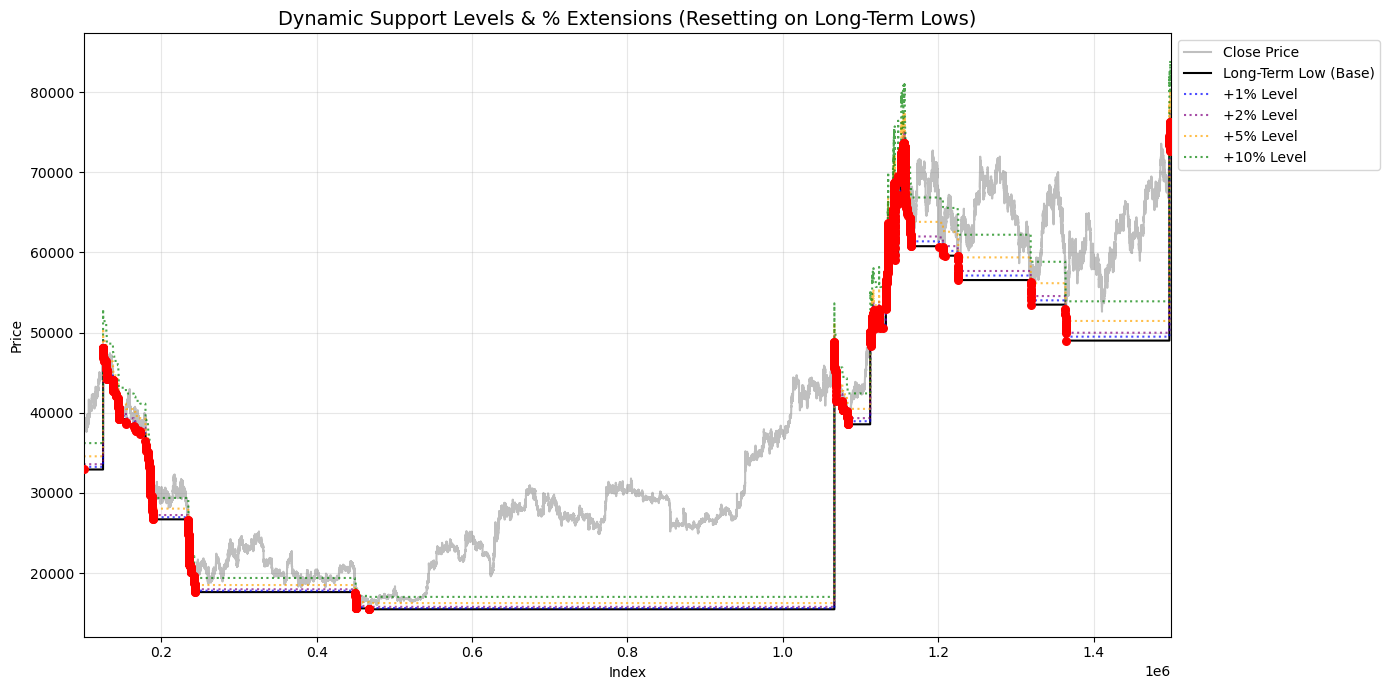

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Calculate long_term_low and its grouping indexes (safe from duplicates) ---
df['long_term_low'] = df.groupby('last_ath_idx')['low'].cummin()

row_positions = np.arange(len(df))
is_ltl = (df['low'].values == df['long_term_low'].values)
ltl_triggers = np.where(is_ltl, row_positions, np.nan)
df['last_ltl_idx'] = pd.Series(ltl_triggers).ffill().values

# --- 2. Calculate the target percentage levels ---
# These will automatically scale/reset based on the active long_term_low
pct_levels = [0.01, 0.02, 0.05, 0.10]
for pct in pct_levels:
    # Level = LTL * (1 + pct)
    df[f'level_{int(pct*100)}pct'] = df['long_term_low'] * (1 + pct)

# --- 3. Slice the cutout for plotting ---
t1, t2 = 100_000, 1_500_000
df_cutout = df.iloc[t1:t2].copy()

# Identify where the LTL actually resets *within this cutout*
# A reset happens when the LTL value changes to a new lower value
ltl_resets = df_cutout[df_cutout['long_term_low'].diff() != 0]

# --- 4. Plotting ---
plt.figure(figsize=(14, 7))

# Plot close price and the baseline long_term_low
plt.plot(df_cutout.index, df_cutout['close'], label='Close Price', color='gray', alpha=0.5)
plt.plot(df_cutout.index, df_cutout['long_term_low'], label='Long-Term Low (Base)', color='black', linewidth=1.5)

# Plot percentage level bands with distinct colors
colors = {0.01: 'blue', 0.02: 'purple', 0.05: 'orange', 0.10: 'green'}
for pct in pct_levels:
    pct_label = f'{int(pct*100)}%'
    col_name = f'level_{int(pct*100)}pct'
    plt.plot(df_cutout.index, df_cutout[col_name], label=f'+{pct_label} Level', color=colors[pct], linestyle=':', alpha=0.7)

# Add clean text annotations on the chart whenever a reset occurs
# To keep the chart clean, we annotate at the start of each new LTL boundary
for idx, row in ltl_resets.iterrows():
    base_val = row['long_term_low']
    # Plot a small red dot at the reset trigger
    plt.scatter(idx, base_val, color='red', s=30, zorder=5)

plt.title("Dynamic Support Levels & % Extensions (Resetting on Long-Term Lows)", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Price")
plt.xlim(t1, t2)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Put legend outside so it doesn't block the chart
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
local_window = 50
rolling_window = 1000

# 1. Calculate absolute All-Time High (ATH)
df['ath_val'] = df['high'].cummax()
df['is_ath'] = df['high'] >= df['ath_val']

# --- THE FIX: Calculate distance in terms of row-indices, not dates ---
# Create an array of row integer indices [0, 1, 2, ...]
row_indices = pd.Series(np.arange(len(df)), index=df.index)

# Locate the row index where each ATH occurs, and ffill it forward
df['last_ath_idx'] = row_indices.where(df['is_ath']).ffill()

# Now the subtraction yields clean integers (0, 1, 2, ... steps)
df['steps_since_ath'] = row_indices - df['last_ath_idx']
# ----------------------------------------------------------------------


# 2. Detect local swing points
df['is_local_high'] = (df['high'] == df['high'].rolling(window=local_window*2).max())
df['is_local_low'] = (df['low'] == df['low'].rolling(window=local_window*2+1).min())

# 3. Calculate standard 1000-timestep rolling maximum
df['is_longer_high'] = (df['high']==df['high'].rolling(window=rolling_window, min_periods=1).max())



# 6. Define the Long-Term High based on our Hybrid Baseline
df['is_lt_high'] = (
    df['is_local_high'] & 
    df['is_longer_high'] &
    (~df['is_ath'])
)
#df['is_flat'] &

# 7. Long-Term Low (remains structurally tied to the lowest local low in this era)
df['ath_era'] = df['is_ath'].cumsum()
df['last_local_low_val'] = df['low'].where(df['is_local_low']).groupby(df['ath_era']).ffill()
df['lt_low_val'] = df.groupby('ath_era')['last_local_low_val'].cummin()
df['is_lt_low'] = df['is_local_low'] & (df['low'] == df['lt_low_val'])# & df['is_flat'] 

# 8. Apply states in hierarchical order
conditions = [
    df['is_ath'],
    df['is_lt_high'],
    df['is_lt_low'],
    df['is_local_high'],
    df['is_local_low']
]

choices = ['all time high', 'long term high', 'long term low', 'local high', 'local low']
df['state'] = np.select(conditions, choices, default='normal')

# Clean up temporary processing columns
df.drop(columns=['ath_val', 'steps_since_ath', 'rolling_max_high', 
                 'hybrid_baseline_high', 'ath_era', 'last_local_low_val', 'lt_low_val'], 
        errors='ignore', inplace=True)

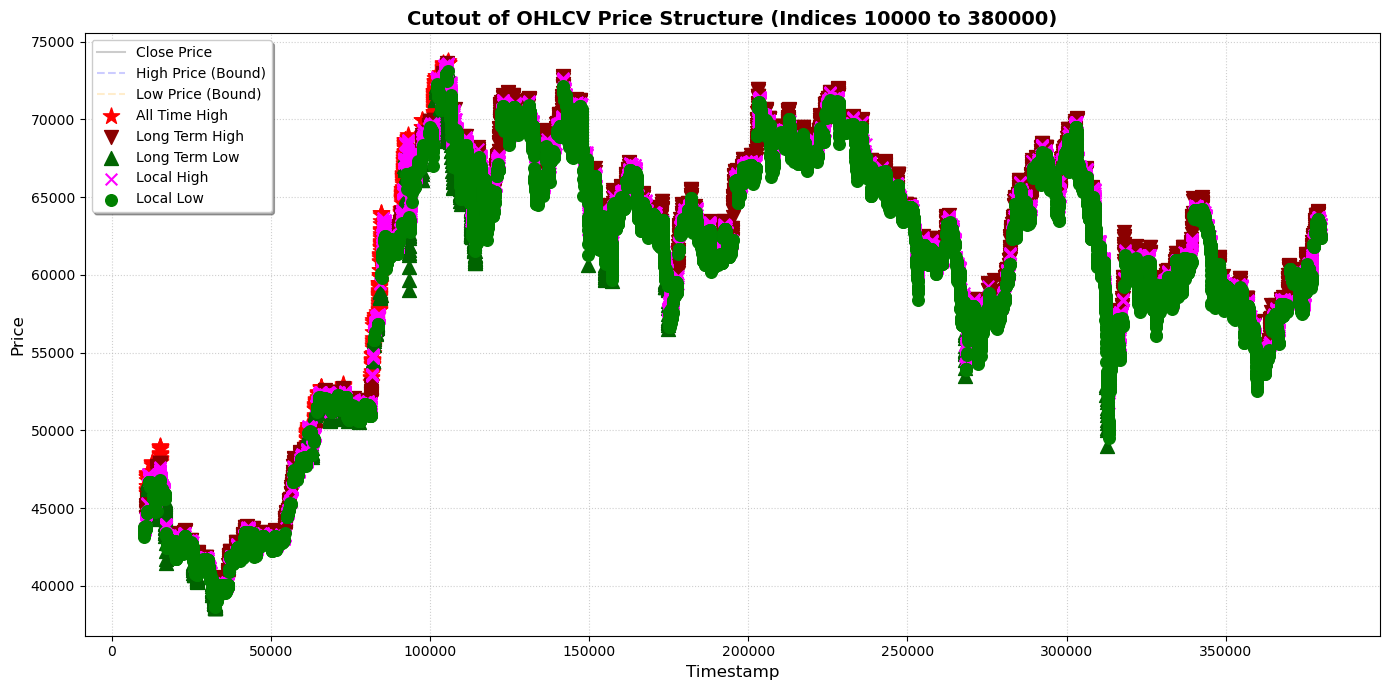

In [14]:

# --- 2. Slice the Data ---
t1, t2 = 10000, 380000
df_cutout = df.iloc[t1:t2].copy()

# --- 3. Plot the Cutout ---
fig, ax = plt.subplots(figsize=(14, 7))

# Plot baseline price activity for the sliced range
ax.plot(df_cutout.index, df_cutout['close'], label='Close Price', color='gray', alpha=0.4, linewidth=1.5)
ax.plot(df_cutout.index, df_cutout['high'], label='High Price (Bound)', color='blue', alpha=0.2, linestyle='--')
ax.plot(df_cutout.index, df_cutout['low'], label='Low Price (Bound)', color='orange', alpha=0.2, linestyle='--')

# Styling map for the state markers
colors = {
    'all time high': 'red',
    'long term high': 'darkred',
    'long term low': 'darkgreen',
    'local high': 'magenta',
    'local low': 'green'
}

markers = {
    'all time high': '*',
    'long term high': 'v',
    'long term low': '^',
    'local high': 'x',
    'local low': 'o'
}

sizes = {
    'all time high': 150,
    'long term high': 100,
    'long term low': 100,
    'local high': 70,
    'local low': 70
}

# Overlay the states only for the sliced range
for state_name in choices:
    state_df = df_cutout[df_cutout['state'] == state_name]
    if not state_df.empty:
        # High states plotted at daily 'high', low states plotted at daily 'low'
        y_vals = state_df['high'] if 'high' in state_name else state_df['low']
        ax.scatter(
            state_df.index, y_vals, 
            color=colors[state_name], 
            marker=markers[state_name], 
            s=sizes[state_name], 
            label=state_name.title(), 
            zorder=5
        )

# Format axes and titles
ax.set_title(f'Cutout of OHLCV Price Structure (Indices {t1} to {t2})', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.legend(loc='upper left', frameon=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
# --- MEAN REVERSION HYPOTHESIS TESTING ---

# Define the horizons you want to test
horizons = [5, 20, 30, 45, 60]

# We use the 'close' price to check if it has reverted relative to the extreme price at time 't'
# shift(-k) looks FORWARD k timesteps into the future
for k in horizons:
    df[f'close_plus_{k}'] = df['close'].shift(-k)

# Initialize a list to store our results
results = []

# Group by the states you defined (excluding 'normal')
states_to_test = ['all time high', 'long term high', 'local high', 'long term low', 'local low']

for state in states_to_test:
    # Filter for rows where this specific state occurs
    state_df = df[df['state'] == state].copy()
    
    # If the state never occurs in the dataset, skip it
    if len(state_df) == 0:
        continue
        
    state_results = {'State': state, 'Total Occurrences': len(state_df)}
    
    for k in horizons:
        future_close = state_df[f'close_plus_{k}']
        
        if 'high' in state:
            # Reversion success: future price is LOWER than the high at time t
            success = future_close < state_df['high']
        else:
            # Reversion success: future price is HIGHER than the low at time t
            success = future_close > state_df['low']
            
        # Calculate the percentage of successful reversions
        # (dropna handles cases near the very end of the dataset)
        success_rate = success.mean() * 100 if not success.dropna().empty else np.nan
        state_results[f'{k} steps (%)'] = round(success_rate, 2)
        
    results.append(state_results)

# Convert results into a clean, scannable DataFrame
summary_df = pd.DataFrame(results)

# Clean up the lookforward columns we temporarily added to df
df.drop(columns=[f'close_plus_{k}' for k in horizons], errors='ignore', inplace=True)

# Display the final summary table
print("\n=== Mean Reversion Success Probability ===")
display(summary_df)


=== Mean Reversion Success Probability ===


,State,Total Occurrences,5 steps (%),20 steps (%),30 steps (%),45 steps (%),60 steps (%)
0,all time high,966,62.11,57.45,58.90,58.90,56.21
1,long term high,13082,63.64,61.53,60.69,60.20,60.14
2,local high,48860,63.17,60.24,58.82,57.73,57.00
3,long term low,2869,67.86,65.60,64.20,64.20,64.66
4,local low,57461,63.62,61.07,60.37,58.94,58.67


In [143]:
# --- SIMPLIFIED BACKTESTING ENGINE WITH FEES ---

# Define the transaction fee per transaction (0.07% = 0.0007)
fee_per_transaction = 0.0007
round_trip_fee = fee_per_transaction * 2  # Applied to entry and exit

# Ensure we have a close price to calculate trade returns
if 'close' not in df.columns:
    df['close'] = (df['high'] + df['low']) / 2

# Track state variables
position = 0       # 0 = flat, 1 = long, -1 = short
entry_price = 0.0
entry_time = None
trades = []        # To record details of each completed trade

for i in range(len(df)):
    current_state = df['state'].iloc[i]
    current_price = df['close'].iloc[i]
    current_time = df.index[i]
    
    # --- 1. HANDLE EXISTING POSITIONS ---
    if position == 1:  # Currently Long
        # EXIT LONG: when state is 'local high'
        if current_state == 'local high':
            # Gross profit/loss
            gross_pnl = (current_price - entry_price) / entry_price
            # Net profit/loss after 2x 0.07% fees
            net_pnl = gross_pnl - round_trip_fee
            
            trades.append({
                'Type': 'Long',
                'Entry Time': entry_time,
                'Exit Time': current_time,
                'Entry Price': entry_price,
                'Exit Price': current_price,
                'Gross PnL (%)': round(gross_pnl * 100, 3),
                'Net PnL (%)': round(net_pnl * 100, 3)
            })
            position = 0  # Return to flat
            
    elif position == -1:  # Currently Short
        # EXIT SHORT: when state is 'local low'
        if current_state == 'local low':
            # Gross profit/loss
            gross_pnl = (entry_price - current_price) / entry_price
            # Net profit/loss after 2x 0.07% fees
            net_pnl = gross_pnl - round_trip_fee
            
            trades.append({
                'Type': 'Short',
                'Entry Time': entry_time,
                'Exit Time': current_time,
                'Entry Price': entry_price,
                'Exit Price': current_price,
                'Gross PnL (%)': round(gross_pnl * 100, 3),
                'Net PnL (%)': round(net_pnl * 100, 3)
            })
            position = 0  # Return to flat

    # --- 2. LOOK FOR NEW ENTRIES (Only if flat) ---
    # Using 'elif' ensures we don't entry-trigger on the same step we exited
    elif position == 0:
        # ENTER LONG: when state is 'long term low'
        if current_state == 'long term low':
            position = 1
            entry_price = current_price
            entry_time = current_time
        # ENTER SHORT: when state is either 'long term high' or 'all time high'
        elif current_state in ['long term high', 'all time high']:
            position = -1
            entry_price = current_price
            entry_time = current_time

# --- 3. PERFORMANCE METRICS GENERATION ---
trades_df = pd.DataFrame(trades)

print("\n=== Backtest Performance Summary (0.07% Fee per Trade) ===")
if not trades_df.empty:
    total_trades = len(trades_df)
    winning_trades = trades_df[trades_df['Net PnL (%)'] > 0]
    win_rate = (len(winning_trades) / total_trades) * 100
    
    total_gross_pnl = trades_df['Gross PnL (%)'].sum()
    total_net_pnl = trades_df['Net PnL (%)'].sum()
    avg_net_pnl = trades_df['Net PnL (%)'].mean()
    
    print(f"Total Trades Executed : {total_trades}")
    print(f"Net Win Rate          : {win_rate:.2f}%")
    print(f"Cumulative Gross Return: {total_gross_pnl:.2f}%")
    print(f"Cumulative Net Return  : {total_net_pnl:.2f}% (After Fees)")
    print(f"Average Net Return/Trade: {avg_net_pnl:.3f}%")
    
    print("\n--- Last 10 Executed Trades (Including Fees) ---")
    print(trades_df[['Type', 'Entry Price', 'Exit Price', 'Gross PnL (%)', 'Net PnL (%)']].tail(10).to_string(index=False))
else:
    print("No trades were triggered. Verify your state definitions and dataset size.")


=== Backtest Performance Summary (0.07% Fee per Trade) ===
Total Trades Executed : 375
Net Win Rate          : 56.80%
Cumulative Gross Return: -9.92%
Cumulative Net Return  : -62.41% (After Fees)
Average Net Return/Trade: -0.166%

--- Last 10 Executed Trades (Including Fees) ---
 Type  Entry Price  Exit Price  Gross PnL (%)  Net PnL (%)
Short     66213.68    66503.82         -0.438       -0.578
 Long     59269.99    60706.00          2.423        2.283
 Long     58440.00    59656.00          2.081        1.941
 Long     58380.84    58649.86          0.461        0.321
 Long     58141.99    58826.01          1.176        1.036
Short     61364.93    61451.02         -0.140       -0.280
Short     62322.00    62532.95         -0.338       -0.478
Short     63164.69    63222.60         -0.092       -0.232
Short     63956.00    63572.22          0.600        0.460
Short     64854.15    64465.89          0.599        0.459



### velocity

is the velocity exceptionally high or low? is it close to 0?

### acceleration 

is acceleration high, low or close to 0?